# Полный пайплайн распознавания эмоций (Audio+Video cascade)

**Схема:**
1. Вход: видео (.mp4). Аудио извлекается из видео — предполагаем, что отдельного аудиофайла нет.
2. **Audio branch** — Log-Mel + CNN: бинарная классификация *neutral vs emotional*.
3. Если `neutral` → итог = `neutral` (в RAVDESS `calm` трактуется как `neutral`).
4. Иначе → **Video branch** — EfficientNet-B0 + Attention Pooling: 8-классовая классификация эмоции.

**Датасет:** все full-AV видео RAVDESS (modality=01).

**Метрики:** accuracy, F1 (macro), confusion matrix, доля ухода в видео-ветку, время на стадию, размер моделей.

In [ ]:
import os, json, time, warnings, gc
warnings.filterwarnings('ignore')

import cv2
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f'Device: {device}')

RAVDESS_PATH = '../datasets/ravdess/'
AUDIO_CKPT_DIR = '../trained_models/audio_neutral'
VIDEO_CKPT_DIR = '../trained_models/video_emotion'
FACE_DETECTOR_PATH = '../raw_models/blaze_face_short_range.tflite'

EMOTION_MAP = {
    1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
    5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised',
}
EMOTION_NAMES = [EMOTION_MAP[i + 1] for i in range(8)]

# В RAVDESS `calm` трактуется как `neutral` для оценки
NEUTRAL_LIKE = {0, 1}  # 0=neutral, 1=calm  (после emotion-1)


def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2

Device: mps


## 1. Сбор видео RAVDESS

Берём все full-AV видео (`modality=01`) из `Video_Speech_Actor_*`.

In [3]:
video_paths, emo_labels, actor_ids = [], [], []

for d in sorted(os.listdir(RAVDESS_PATH)):
    if not d.startswith('Video_Speech_Actor_'):
        continue
    for actor_sub in sorted(os.listdir(os.path.join(RAVDESS_PATH, d))):
        if not actor_sub.startswith('Actor_'):
            continue
        actor_path = os.path.join(RAVDESS_PATH, d, actor_sub)
        for f in sorted(os.listdir(actor_path)):
            if not f.endswith('.mp4'):
                continue
            parts = f.replace('.mp4', '').split('-')
            if int(parts[0]) != 1:  # только full-AV
                continue
            video_paths.append(os.path.join(actor_path, f))
            emo_labels.append(int(parts[2]) - 1)  # 0..7
            actor_ids.append(int(parts[6]))

emo_labels = np.array(emo_labels)
actor_ids = np.array(actor_ids)
print(f'Всего full-AV видео: {len(video_paths)} | Актёров: {len(set(actor_ids))}')
for i, name in enumerate(EMOTION_NAMES):
    print(f'  {name:10s} {(emo_labels == i).sum()}')

Всего full-AV видео: 1440 | Актёров: 24
  neutral    96
  calm       192
  happy      192
  sad        192
  angry      192
  fearful    192
  disgust    192
  surprised  192


## 2. Загрузка обученных моделей

* **Audio:** Log-Mel (64×128) → `MelCNN` (бинарная, 0=neutral, 1=emotional)
* **Video:** 16 кадров → MediaPipe face crop (224×224) → EfficientNet-B0 → Attention Pooling → 8 классов

In [4]:
with open(os.path.join(AUDIO_CKPT_DIR, 'meta.json')) as f:
    audio_meta = json.load(f)
with open(os.path.join(VIDEO_CKPT_DIR, 'meta.json')) as f:
    video_meta = json.load(f)

SR = audio_meta['SR']; N_MELS = audio_meta['N_MELS']
MAX_LEN = audio_meta['MAX_LEN']; HOP = audio_meta['HOP']
MEL_MEAN = audio_meta['mel_mean']; MEL_STD = audio_meta['mel_std']

N_CLASSES = video_meta['N_CLASSES']
FEAT_DIM_EFF = video_meta['FEAT_DIM_EFF']
N_FRAMES = video_meta['N_FRAMES']
IMG_SIZE = video_meta['IMG_SIZE']
print(f'Audio meta: {audio_meta}')
print(f'Video meta: {video_meta}')

Audio meta: {'SR': 16000, 'N_MELS': 64, 'MAX_LEN': 128, 'HOP': 512, 'N_MFCC': 40, 'mel_mean': -33.17436218261719, 'mel_std': 27.39727783203125, 'hub_dim': 768}
Video meta: {'N_CLASSES': 8, 'FEAT_DIM': 576, 'FEAT_DIM_EFF': 1280, 'N_FRAMES': 16, 'IMG_SIZE': 224}


In [5]:
class MelCNN(nn.Module):
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class AttentionPoolingClassifier(nn.Module):
    def __init__(self, feat_dim=1280, n_classes=8, hidden=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.Tanh(), nn.Linear(64, 1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x):
        w = torch.softmax(self.attention(x), dim=1)
        pooled = (w * x).sum(dim=1)
        return self.classifier(pooled)

In [6]:
mel_cnn = MelCNN(N_MELS, MAX_LEN).to(device)
mel_cnn.load_state_dict(torch.load(os.path.join(AUDIO_CKPT_DIR, 'mel_cnn.pt'), map_location=device))
mel_cnn.eval()

efficientnet = tv_models.efficientnet_b0(weights=None)
efficientnet.classifier = nn.Identity()
eff_state = torch.load(os.path.join(VIDEO_CKPT_DIR, 'efficientnet_b0_backbone.pt'), map_location=device)
efficientnet.load_state_dict(eff_state)
efficientnet = efficientnet.to(device).eval()

attn_head = AttentionPoolingClassifier(FEAT_DIM_EFF, N_CLASSES).to(device)
attn_head.load_state_dict(torch.load(os.path.join(VIDEO_CKPT_DIR, 'head_efficientnet_attention.pt'), map_location=device))
attn_head.eval()

mel_cnn_mb = pytorch_size_mb(mel_cnn)
eff_mb = pytorch_size_mb(efficientnet)
head_mb = pytorch_size_mb(attn_head)
print(f'MelCNN: {mel_cnn_mb:.2f} MB')
print(f'EfficientNet-B0: {eff_mb:.2f} MB')
print(f'Attention head: {head_mb:.2f} MB')
print(f'Всего: {mel_cnn_mb + eff_mb + head_mb:.2f} MB')

MelCNN: 2.09 MB
EfficientNet-B0: 15.45 MB
Attention head: 0.94 MB
Всего: 18.48 MB


In [7]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

_face_detector = mp_vision.FaceDetector.create_from_options(
    mp_vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=FACE_DETECTOR_PATH),
        min_detection_confidence=0.5,
    )
)

imagenet_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print('Face detector ready')

Face detector ready


I0000 00:00:1776618295.435788 21936161 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776618295.441458 21936162 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 3. Инференс-утилиты

In [8]:
def load_audio_from_video(video_path, sr=SR):
    """librosa.load читает аудиодорожку из .mp4 через audioread/ffmpeg."""
    y, _ = librosa.load(video_path, sr=sr, mono=True)
    return y


def audio_is_neutral(y):
    """Log-Mel + CNN → (is_neutral: bool, prob_emotional: float)."""
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    lm = (lm - MEL_MEAN) / (MEL_STD + 1e-8)
    xt = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = mel_cnn(xt)
        prob = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred = int(logits.argmax(1).item())
    return pred == 0, float(prob[1])

In [9]:
def extract_frames(video_path, n_frames=N_FRAMES):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def detect_and_crop_face(frame, target_size=IMG_SIZE):
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    result = _face_detector.detect(mp_img)
    if result.detections:
        bb = result.detections[0].bounding_box
        h, w = frame.shape[:2]
        pad_x = int(bb.width * 0.1); pad_y = int(bb.height * 0.1)
        x1 = max(0, bb.origin_x - pad_x)
        y1 = max(0, bb.origin_y - pad_y)
        x2 = min(w, bb.origin_x + bb.width + pad_x)
        y2 = min(h, bb.origin_y + bb.height + pad_y)
        if x2 > x1 and y2 > y1:
            return cv2.resize(frame[y1:y2, x1:x2], (target_size, target_size))
    h, w = frame.shape[:2]; s = min(h, w)
    y1, x1 = (h - s) // 2, (w - s) // 2
    return cv2.resize(frame[y1:y1 + s, x1:x1 + s], (target_size, target_size))


def video_predict_emotion(video_path):
    """Frames → faces → EfficientNet → Attention head → 8 классов."""
    frames = extract_frames(video_path, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops]).to(device)
    with torch.no_grad():
        feats = efficientnet(faces).unsqueeze(0)
        logits = attn_head(feats)
    return int(logits.argmax(1).item())

In [10]:
def full_pipeline(video_path):
    """Каскад: audio-neutral? → если нет, видео-классификатор."""
    timings = {}
    t0 = time.perf_counter()
    y = load_audio_from_video(video_path)
    timings['audio_load'] = time.perf_counter() - t0

    t0 = time.perf_counter()
    is_neutral, prob_emo = audio_is_neutral(y)
    timings['audio_infer'] = time.perf_counter() - t0

    if is_neutral:
        return {'pred': 0, 'routed_to_video': False,
                'prob_emotional': prob_emo, 'timings': timings}

    t0 = time.perf_counter()
    pred = video_predict_emotion(video_path)
    timings['video_infer'] = time.perf_counter() - t0
    return {'pred': pred, 'routed_to_video': True,
            'prob_emotional': prob_emo, 'timings': timings}

## 4. Запуск по всему RAVDESS

In [11]:
preds = np.zeros(len(video_paths), dtype=int)
routed = np.zeros(len(video_paths), dtype=bool)
timings_audio_load = np.zeros(len(video_paths))
timings_audio_infer = np.zeros(len(video_paths))
timings_video_infer = np.full(len(video_paths), np.nan)

t_total = time.perf_counter()
for i, vp in enumerate(tqdm(video_paths, desc='Pipeline')):
    r = full_pipeline(vp)
    preds[i] = r['pred']
    routed[i] = r['routed_to_video']
    timings_audio_load[i] = r['timings']['audio_load']
    timings_audio_infer[i] = r['timings']['audio_infer']
    if r['routed_to_video']:
        timings_video_infer[i] = r['timings']['video_infer']
total_time = time.perf_counter() - t_total
print(f'Готово: {len(video_paths)} видео за {total_time:.1f} сек ({total_time/len(video_paths)*1000:.1f} мс/видео)')

Pipeline: 100%|██████████| 1440/1440 [07:00<00:00,  3.42it/s]

Готово: 1440 видео за 420.7 сек (292.1 мс/видео)


## 5. Метрики

`calm` (label=1) сворачивается в `neutral` (label=0) и для ground truth, и для предсказаний → 7 итоговых классов.

In [12]:
def collapse(lbl):
    return 0 if lbl in NEUTRAL_LIKE else lbl

y_true_coll = np.array([collapse(x) for x in emo_labels])
y_pred_coll = np.array([collapse(x) for x in preds])

present = sorted(set(y_true_coll.tolist()) | set(y_pred_coll.tolist()))
target_names = [EMOTION_NAMES[i] for i in present]

acc = accuracy_score(y_true_coll, y_pred_coll)
f1m = f1_score(y_true_coll, y_pred_coll, average='macro')
prec = precision_score(y_true_coll, y_pred_coll, average='macro', zero_division=0)
rec = recall_score(y_true_coll, y_pred_coll, average='macro', zero_division=0)
print(f'Accuracy : {acc:.4f}')
print(f'F1 macro : {f1m:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print()
print(classification_report(y_true_coll, y_pred_coll, labels=present, target_names=target_names, zero_division=0))

Accuracy : 0.8187
F1 macro : 0.8130
Precision: 0.8526
Recall   : 0.8070

              precision    recall  f1-score   support

     neutral       0.70      0.98      0.82       288
       happy       0.95      0.88      0.91       192
         sad       0.87      0.54      0.67       192
       angry       0.78      0.94      0.86       192
     fearful       0.77      0.87      0.81       192
     disgust       0.92      0.82      0.87       192
   surprised       0.97      0.61      0.75       192

    accuracy                           0.82      1440
   macro avg       0.85      0.81      0.81      1440
weighted avg       0.84      0.82      0.81      1440



In [13]:
n_video = int(routed.sum())
n_audio_only = len(routed) - n_video
print(f'Ушло в аудио-ветку (neutral):   {n_audio_only} ({n_audio_only/len(routed)*100:.1f}%)')
print(f'Ушло в видео-ветку (emotional): {n_video} ({n_video/len(routed)*100:.1f}%)')

y_true_bin = np.array([0 if l in NEUTRAL_LIKE else 1 for l in emo_labels])
y_pred_bin = routed.astype(int)
gate_acc = accuracy_score(y_true_bin, y_pred_bin)
gate_f1 = f1_score(y_true_bin, y_pred_bin, average='macro')
print(f'\nКачество аудио-гейта (neutral vs emotional):')
print(f'  Accuracy: {gate_acc:.4f}  |  F1 macro: {gate_f1:.4f}')

mask_vid_correct_route = routed & (y_true_bin == 1)
if mask_vid_correct_route.sum() > 0:
    vid_acc = accuracy_score(emo_labels[mask_vid_correct_route], preds[mask_vid_correct_route])
    vid_f1 = f1_score(emo_labels[mask_vid_correct_route], preds[mask_vid_correct_route], average='macro')
    print(f'\nКачество видео-классификатора на корректно направленных видео (N={int(mask_vid_correct_route.sum())}):')
    print(f'  Accuracy: {vid_acc:.4f}  |  F1 macro: {vid_f1:.4f}')

Ушло в аудио-ветку (neutral):   367 (25.5%)
Ушло в видео-ветку (emotional): 1073 (74.5%)

Качество аудио-гейта (neutral vs emotional):
  Accuracy: 0.9257  |  F1 macro: 0.8943

Качество видео-классификатора на корректно направленных видео (N=1059):
  Accuracy: 0.8461  |  F1 macro: 0.6409


## 6. Визуализация

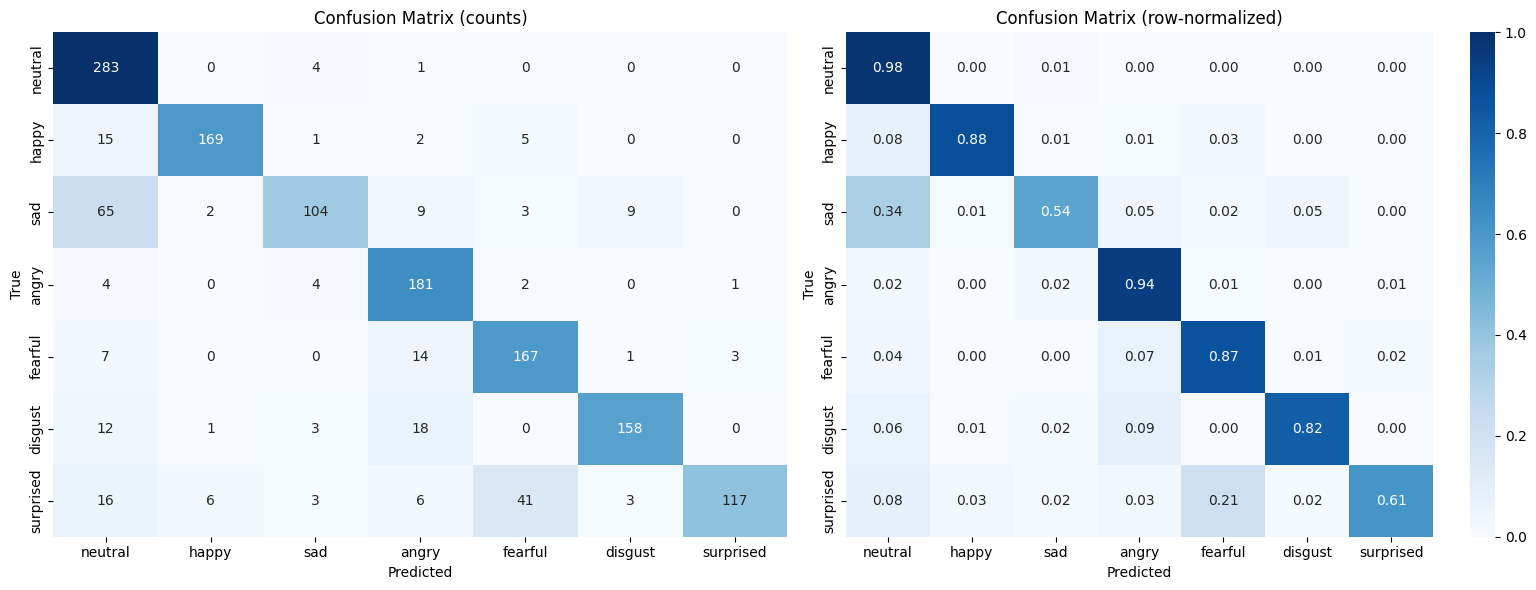

In [14]:
cm = confusion_matrix(y_true_coll, y_pred_coll, labels=present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1], cbar=True, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (row-normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout(); plt.show()

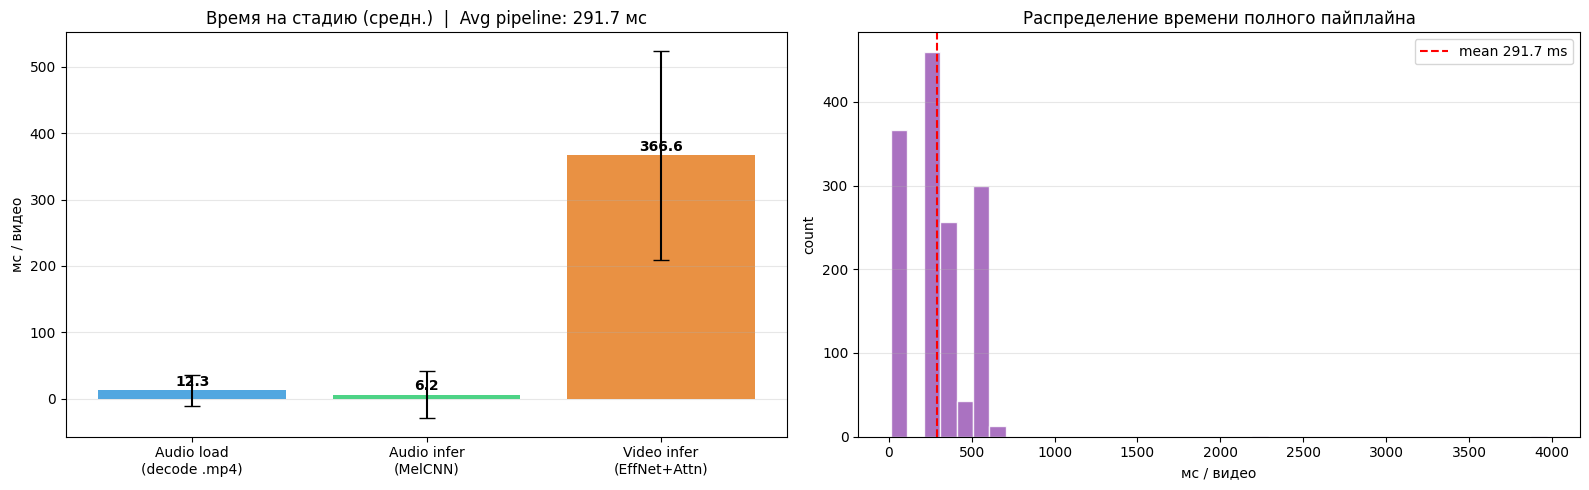

In [15]:
audio_load_ms = timings_audio_load * 1000
audio_infer_ms = timings_audio_infer * 1000
video_infer_ms_only = timings_video_infer[~np.isnan(timings_video_infer)] * 1000

stages = ['Audio load\n(decode .mp4)', 'Audio infer\n(MelCNN)', 'Video infer\n(EffNet+Attn)']
means = [audio_load_ms.mean(), audio_infer_ms.mean(),
         float(video_infer_ms_only.mean()) if len(video_infer_ms_only) else 0.0]
stds = [audio_load_ms.std(), audio_infer_ms.std(),
        float(video_infer_ms_only.std()) if len(video_infer_ms_only) else 0.0]

avg_pipeline_ms = audio_load_ms.mean() + audio_infer_ms.mean() + \
    (video_infer_ms_only.sum() / len(video_paths) if len(video_infer_ms_only) else 0.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#3498db', '#2ecc71', '#e67e22']
bars = axes[0].bar(stages, means, yerr=stds, capsize=6, color=colors, alpha=0.85)
axes[0].set_ylabel('мс / видео')
axes[0].set_title(f'Время на стадию (средн.)  |  Avg pipeline: {avg_pipeline_ms:.1f} мс')
axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + max(means) * 0.02,
                 f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

per_video_total_ms = audio_load_ms + audio_infer_ms + np.nan_to_num(timings_video_infer * 1000, nan=0.0)
axes[1].hist(per_video_total_ms, bins=40, color='#9b59b6', alpha=0.85, edgecolor='white')
axes[1].axvline(per_video_total_ms.mean(), color='red', linestyle='--',
                label=f'mean {per_video_total_ms.mean():.1f} ms')
axes[1].set_xlabel('мс / видео'); axes[1].set_ylabel('count')
axes[1].set_title('Распределение времени полного пайплайна')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

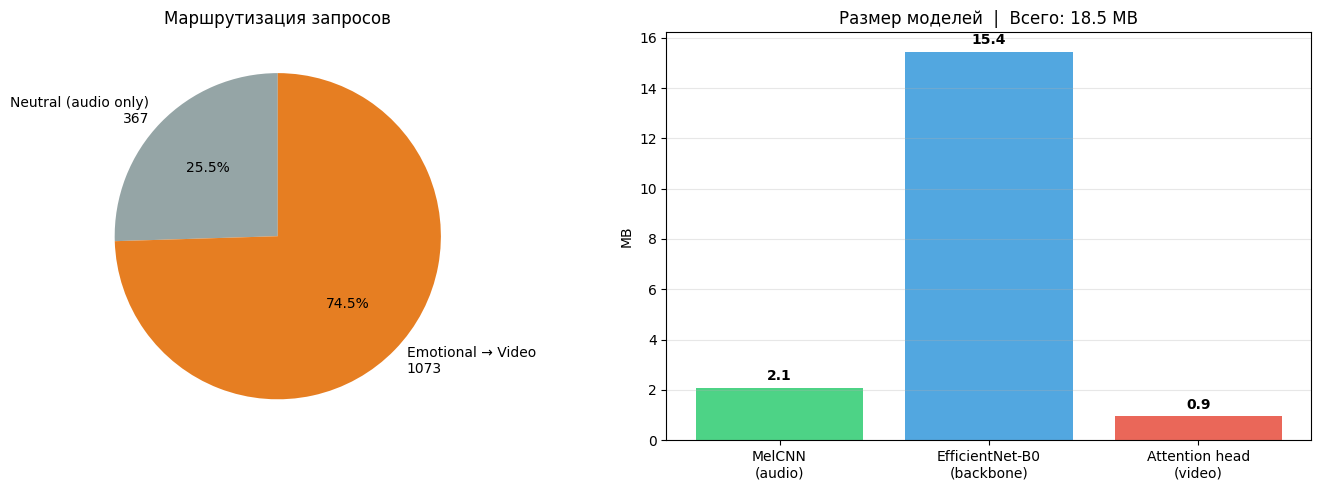

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie([n_audio_only, n_video],
            labels=[f'Neutral (audio only)\n{n_audio_only}',
                    f'Emotional → Video\n{n_video}'],
            colors=['#95a5a6', '#e67e22'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Маршрутизация запросов')

model_names = ['MelCNN\n(audio)', 'EfficientNet-B0\n(backbone)', 'Attention head\n(video)']
sizes = [mel_cnn_mb, eff_mb, head_mb]
bars = axes[1].bar(model_names, sizes, color=['#2ecc71', '#3498db', '#e74c3c'], alpha=0.85)
axes[1].set_ylabel('MB')
axes[1].set_title(f'Размер моделей  |  Всего: {sum(sizes):.1f} MB')
axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(bars, sizes):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + max(sizes) * 0.02,
                 f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

In [17]:
summary = pd.DataFrame([{
    'Видео всего': len(video_paths),
    'Accuracy (7-cls)': f'{acc:.4f}',
    'F1 macro (7-cls)': f'{f1m:.4f}',
    'Audio-gate Acc': f'{gate_acc:.4f}',
    'Audio-gate F1': f'{gate_f1:.4f}',
    '% → Video': f'{n_video/len(routed)*100:.1f}%',
    'Avg pipeline (ms)': f'{avg_pipeline_ms:.1f}',
    'Total size (MB)': f'{sum(sizes):.1f}',
}])
print(summary.to_string(index=False))

 Видео всего Accuracy (7-cls) F1 macro (7-cls) Audio-gate Acc Audio-gate F1 % → Video Avg pipeline (ms) Total size (MB)
        1440           0.8187           0.8130         0.9257        0.8943     74.5%             291.7            18.5
